 # Prédiction du Risque de Désabonnement Client (Churn)

**PAR :** MOUCHILI Ibrahim et  KABENDE Katya
**NIVEAU ET FILIERE :** M1 Mecatronique – Specialisation Robotique et IA-M2I  
**UNIVERSITE CATHOLIQUE SAINT JEROME DE DOUALA**

---

 ## Objectif du Projet

Ce projet vise à construire un modèle de classification supervisée capable de prédire si un client va se désabonner (Churn = 1) ou rester fidèle (Churn = 0).  
Nous utilisons le dataset Telco Customer Churn (IBM/Kaggle).

---

##  Plan du Notebook

1. **Data Acquisition** – Chargement et première inspection
2. **Data Preparation** – Nettoyage, encodage, normalisation
3. **Splitting** – Train / Test
4. **GridSearchCV** – Recherche des meilleurs hyperparamètres
5. **Évaluation** – Matrice de confusion, métriques (Accuracy, Precision, Recall, F1)
6. **Visualisations** – ROC, Learning Curves, Feature Importance
7. **Interprétation & Recommandations métier**

---
 Notre cible Churn Value est binaire (0 ou 1). La régression linéaire prédirait des valeurs comme 0.73 qui n'ont aucun sens métier ici. On choisit donc la classification supervisée.

In [ ]:


# --- Manipulation de données ---
import pandas as pd          
import numpy as np           

# --- Visualisation ---
import matplotlib.pyplot as plt   
import seaborn as sns              
import plotly.express as px        

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# --- Modèles ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# --- Évaluation ---
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, RocCurveDisplay
)



---
# 1 DATA ACQUISITION – Chargement des Données

## Pourquoi cette étape ?
Avant de faire quoi que ce soit, on doit **comprendre ce qu'on a**.  
Le dataset contient des informations sur les clients d'une entreprise de télécommunications.



In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [21]:

print("=" * 60)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 60)
display(df.head())

APERÇU DES PREMIÈRES LIGNES


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [22]:
# Types de données de chaque colonne
print(df.dtypes)

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object


In [23]:
# Statistiques descriptives des variables numériques
print(" STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(df.describe())

 STATISTIQUES DESCRIPTIVES


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [24]:
# Vérification des valeurs manquantes
print("=" * 60)
print(" VALEURS MANQUANTES PAR COLONNE")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
display(missing_df[missing_df['Manquants'] > 0])
print(f"\nTotal colonnes sans valeurs manquantes : {(missing == 0).sum()} / {len(missing)}")

 VALEURS MANQUANTES PAR COLONNE


,Manquants,Pourcentage (%)
Total Charges,11,0.16
Churn Reason,5174,73.46



Total colonnes sans valeurs manquantes : 31 / 33


---
# 2 EXPLORATION VISUELLE

## Pourquoi visualiser avant de modéliser ?
La visualisation permet de :
- **Comprendre la distribution** de chaque variable
- **Détecter les anomalies** (outliers, déséquilibres de classes)
- **Identifier les corrélations** entre features et target
- **Orienter le prétraitement** (normaliser si distribution asymétrique, etc.)

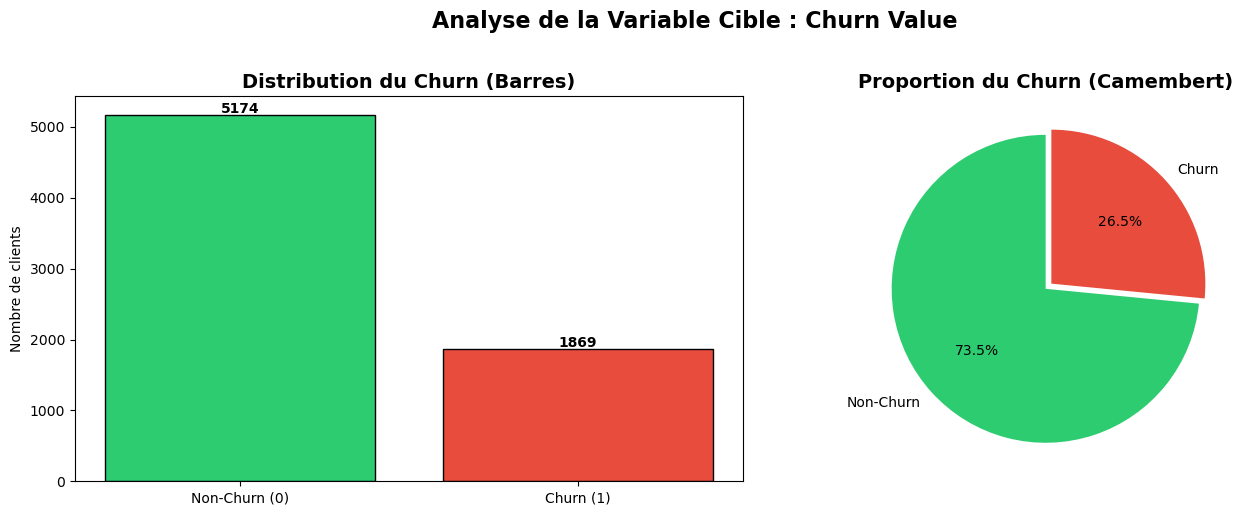


 Ratio Churn/Non-Churn : 0.36
Classes déséquilibrées ! Le modèle risque de favoriser la classe majoritaire.


In [25]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
churn_counts = df['Churn Value'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Vert = resté, Rouge = parti


axes[0].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution du Churn (Barres)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Diagramme circulaire
axes[1].pie(
    churn_counts.values,
    labels=['Non-Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Proportion du Churn (Camembert)', fontsize=14, fontweight='bold')

plt.suptitle('Analyse de la Variable Cible : Churn Value', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Commentaire automatique
ratio = churn_counts[1] / churn_counts[0]
print(f"\n Ratio Churn/Non-Churn : {ratio:.2f}")
if ratio < 0.4:
    print("Classes déséquilibrées ! Le modèle risque de favoriser la classe majoritaire.")
else:
    print("Distribution relativement équilibrée.")

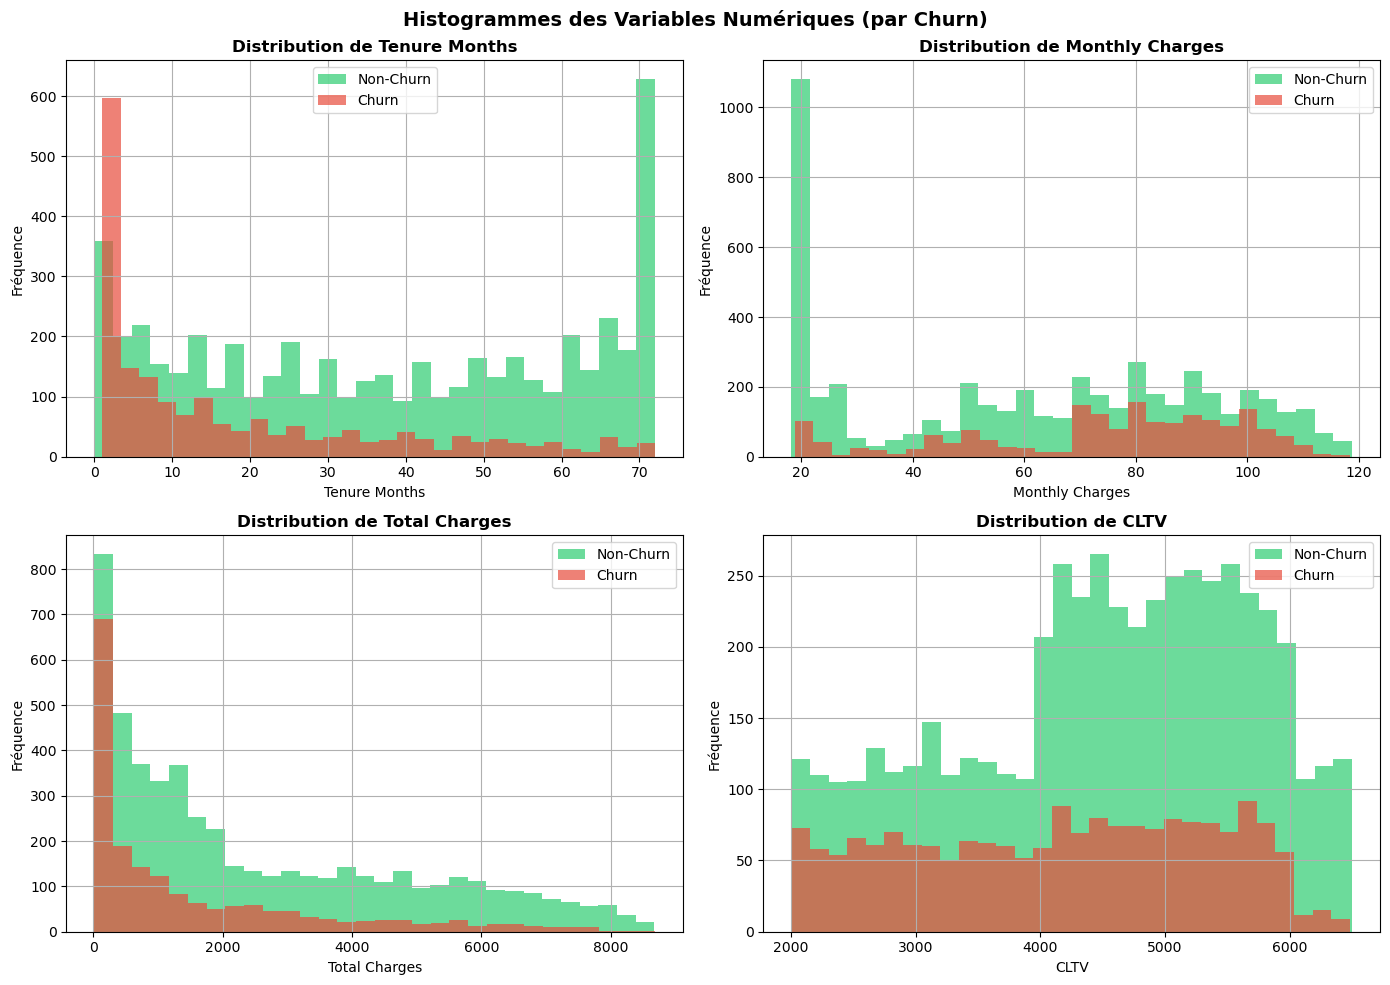

In [26]:


# Identification des colonnes numériques pertinentes
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

# Conversion de Total Charges en numérique
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Histogramme séparé par Churn
    df[df['Churn Value'] == 0][col].dropna().hist(
        ax=axes[i], bins=30, alpha=0.7, color='#2ecc71', label='Non-Churn'
    )
    df[df['Churn Value'] == 1][col].dropna().hist(
        ax=axes[i], bins=30, alpha=0.7, color='#e74c3c', label='Churn' 
    )
    axes[i].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

plt.suptitle('Histogrammes des Variables Numériques (par Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histogrammes_numeriques.png', dpi=150, bbox_inches='tight')
plt.show()

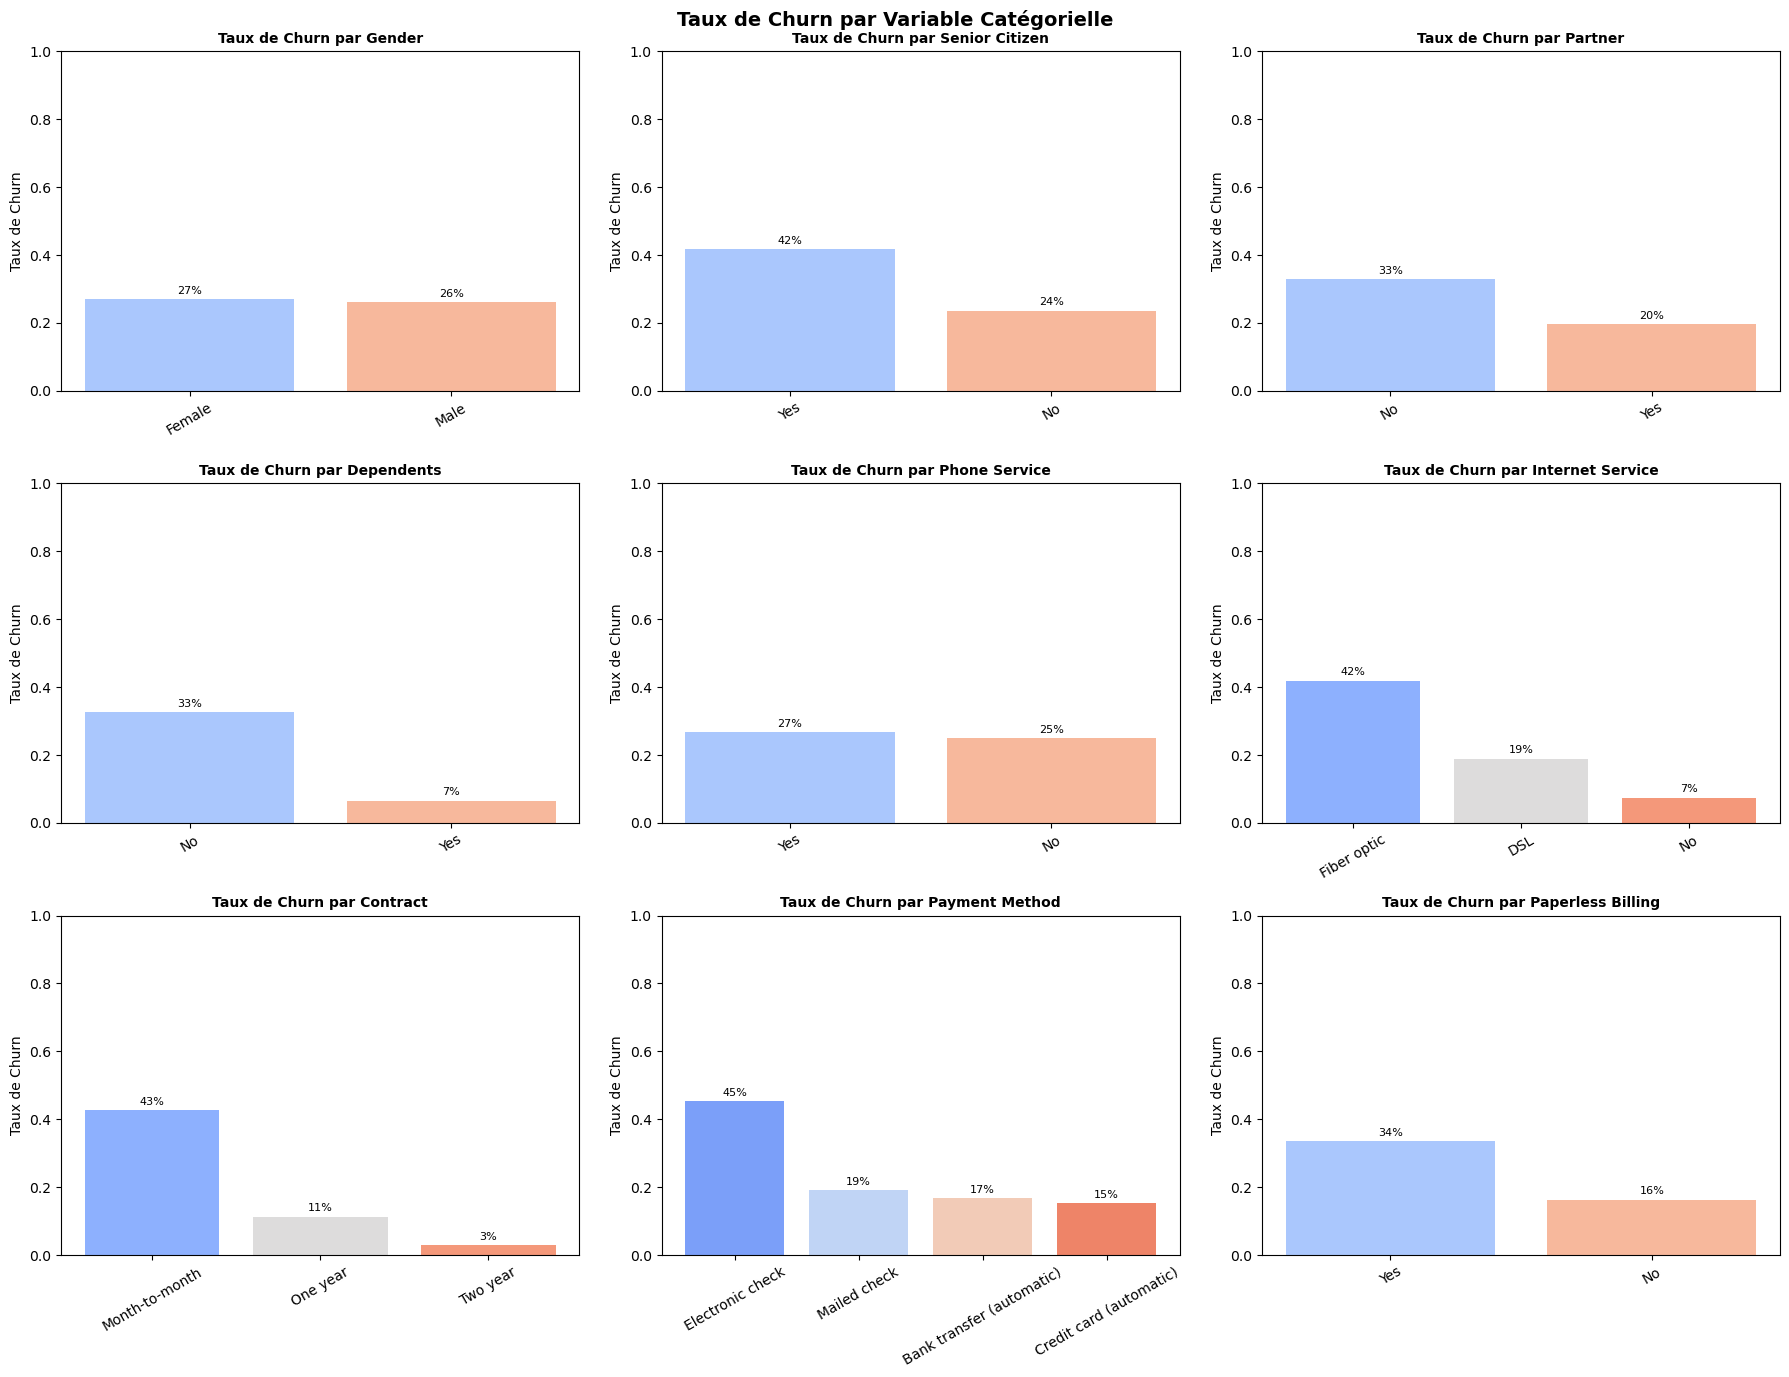

In [ ]:


cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
            'Phone Service', 'Internet Service', 'Contract',
            'Payment Method', 'Paperless Billing']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn Value'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color=sns.color_palette('coolwarm', len(churn_rate)))
    axes[i].set_title(f'Taux de Churn par {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Taux de Churn')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)
    # Ajout des valeurs sur les barres
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}',
                     ha='center', va='bottom', fontsize=8)

plt.suptitle('Taux de Churn par Variable Catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_categoriel.png', dpi=150, bbox_inches='tight')
plt.show()

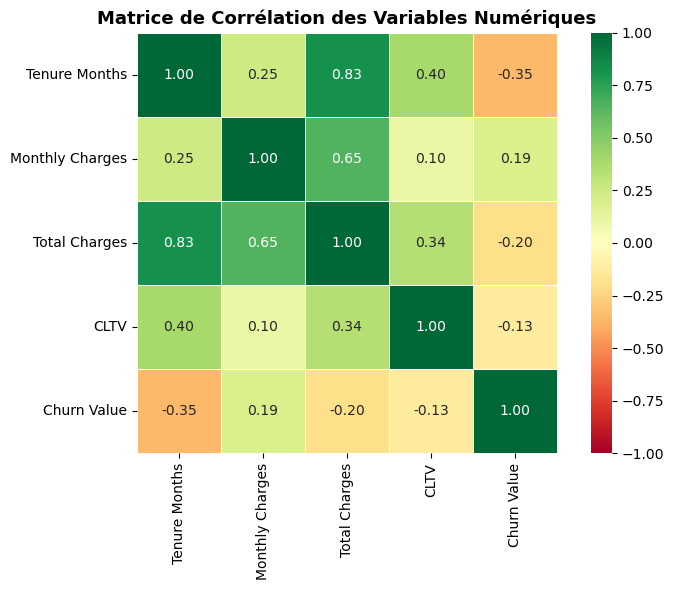


 Interprétation :
  - Corrélation proche de +1 : relation positive forte
  - Corrélation proche de -1 : relation négative forte
  - Corrélation proche de  0 : pas de relation linéaire


In [27]:


# Sélection des colonnes numériques pour la corrélation
corr_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Value']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interprétation :")
print("  - Corrélation proche de +1 : relation positive forte")
print("  - Corrélation proche de -1 : relation négative forte")
print("  - Corrélation proche de  0 : pas de relation linéaire")

---
# 3 DATA PREPARATION – Prétraitement

## Étapes du prétraitement

### 3.1 Suppression des colonnes inutiles
On retire les colonnes qui ne sont pas des **features prédictives :
- Identifiants (CustomerID) uniquement un ID, aucune info prédictive
- Colonnes géographiques brutes (Lat Long, Latitude, Longitude, Zip Code)  trop granulaires et non informatives pour ce modèle
- Colonnes liées au churn data leakage (Churn Label, Churn Reason, Churn Score)

### 3.2 Gestion des valeurs manquantes
Pourquoi la médiane et non la moyenne ? 
La médiane est robuste aux valeurs extrêmes (outliers). Si Total Charges a quelques valeurs aberrantes, la moyenne serait biaisée, pas la médiane.

### 3.3 Encodage des variables catégorielles
Les algorithmes ML ne comprennent que des nombres. On encode :
- Binaire (2 catégories) LabelEncoder (0/1)
- Nominale (3+ catégories) One-Hot Encoding pour éviter d'introduire un ordre artificiel

### 3.4 Standardisation (StandardScaler)
Pourquoi standardiser ? 
Monthly Charges` varie de 0 à 120, Tenure Months` de 0 à 72. Sans normalisation, les grandes valeurs dominent le modèle.  
StandardScaler` transforme chaque feature pour avoir une **moyenne = 0** et un écart-type = 1

In [ ]:


df_clean = df.copy()  # On travaille sur une copie pour préserver l'original

# Colonnes à supprimer (identifiants, géo, data leakage)
cols_to_drop = [
    'CustomerID',     
    'Count',          
    'Country',        
    'State',          
    'City',          
    'Zip Code',      
    'Lat Long',      
    'Latitude',      
    'Longitude',  
    'Churn Label',    
    'Churn Reason',  
]

# Suppression des colonnes existantes
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)

print(f" Colonnes supprimées : {cols_to_drop}")
print(f" Nouvelles dimensions : {df_clean.shape}")
print(f"\nColonnes restantes : {list(df_clean.columns)}")

 Colonnes supprimées : ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Reason']
 Nouvelles dimensions : (7043, 22)

Colonnes restantes : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']


In [31]:


# Conversion de Total Charges en numérique (peut contenir des espaces)
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')

print("Valeurs manquantes avant imputation :")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Imputation par la médiane pour les variables numériques
# Pourquoi la médiane ? Robuste aux outliers contrairement à la moyenne
num_features = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in num_features:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"  → '{col}' : {df_clean[col].isnull().sum()} NaN remplacés par médiane = {median_val:.2f}")

# Imputation par le mode pour les variables catégorielles
cat_features = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_features:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"  → '{col}' : NaN remplacés par mode = '{mode_val}'")

print(f"\n Plus aucune valeur manquante : {df_clean.isnull().sum().sum()} NaN total")

Valeurs manquantes avant imputation :
Series([], dtype: int64)

 Plus aucune valeur manquante : 0 NaN total


In [ ]:


# Séparation features / target AVANT encodage
TARGET = 'Churn Value'
y = df_clean[TARGET].copy()  # Variable cible (0 ou 1)
X = df_clean.drop(columns=[TARGET]).copy()

print(f" Variable cible 'y' : {y.shape[0]} valeurs")
print(f"   Distribution Non-Churn (0): {(y==0).sum()} | Churn (1): {(y==1).sum()}")

# --- Identification des colonnes catégorielles dans X ---
cat_cols_X = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nColonnes catégorielles à encoder ({len(cat_cols_X)}) : {cat_cols_X}")


# Pourquoi OHE et non LabelEncoder pour les catégorielles multi-classes ?
# LabelEncoder attribuerait des valeurs (0,1,2,3...) qui impliquent un ORDRE
# Ex: 'DSL'=0, 'Fiber optic'=1, 'No'=2 → suggère que 'No' > 'Fiber' > 'DSL' → FAUX
# OHE crée des colonnes binaires indépendantes sans ordre artificiel
X_encoded = pd.get_dummies(X, columns=cat_cols_X, drop_first=True)

print(f"\n Après encodage :")
print(f"   Dimensions X : {X.shape} → {X_encoded.shape}")
print(f"   Nouvelles colonnes créées : {X_encoded.shape[1] - X.shape[1]}")

# Conversion des booléens en entiers (si présents)
X_encoded = X_encoded.astype(float)

display(X_encoded.head(3))

 Variable cible 'y' : 7043 valeurs
   Distribution → Non-Churn (0): 5174 | Churn (1): 1869

Colonnes catégorielles à encoder (16) : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

 Après encodage :
   Dimensions X : (7043, 21) → (7043, 32)
   Nouvelles colonnes créées : 11


,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2.0,53.85,108.15,86.0,3239.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2.0,70.70,151.65,67.0,2701.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,8.0,99.65,820.50,86.0,5372.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


---
# 4  SPLITTING – Division Train / Test

## Pourquoi diviser les données ?

On ne peut pas évaluer un modèle sur les mêmes données sur lesquelles il a été entraîné (ce serait comme donner les réponses d'un examen avant l'examen).

**Stratégie :**
- **70% Entraînement** → le modèle apprend les patterns
- **30% Test** → on évalue les performances sur des données inconnues

**`stratify=y`** : Garantit que les proportions de Churn/Non-Churn sont identiques dans train et test (important si les classes sont déséquilibrées).

In [32]:


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.30,        # 30% pour le test
    random_state=42,       # Pour la reproductibilité
    stratify=y             # Préserve les proportions de classes
)



# NORMALISATION (StandardScaler)
# IMPORTANT : on fit le scaler UNIQUEMENT sur le train, puis on transforme train et test
# Pourquoi ? Pour éviter le 'data leakage' (le test ne doit pas influencer la normalisation)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_scaled  = scaler.transform(X_test)         # transform seulement sur test



---
# 5 GRIDSEACHCV – Optimisation des Hyperparamètres

## Qu'est-ce qu'un hyperparamètre ?

Un **paramètre** est appris par le modèle (poids de la régression logistique).  
Un **hyperparamètre** est fixé AVANT l'entraînement (ex: C dans la régression logistique, n_estimators dans la forêt aléatoire).

## Pourquoi GridSearchCV et non une recherche manuelle ?


GridSearchCv avec cv=5 signifie **validation croisée à 5 folds** : les données d'entraînement sont divisées en 5 parties, le modèle est entraîné 5 fois (chaque fois sur 4 parties, évalué sur la 5ème). Cela donne une estimation robuste des performances.

In [33]:

# GRIDSEARCHCV – RÉGRESSION LOGISTIQUE

# Pourquoi la Régression Logistique ?
# → Malgré son nom, c'est un modèle de CLASSIFICATION (pas de régression)
# → Elle prédit la PROBABILITÉ d'appartenir à la classe 1
# → Interprétable : les coefficients indiquent l'impact de chaque feature
# → Bonne baseline avant des modèles plus complexes

print(" GridSearchCV Régression Logistique.")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],          # Régularisation (+ grand = moins régularisé)
    'solver': ['lbfgs', 'liblinear'],        # Algorithme d'optimisation
    'max_iter': [500, 1000]                  # Nombre max d'itérations
}

gs_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,                 # 5-fold cross validation
    scoring='f1',         # Optimiser le F1-score (bon pour classes déséquilibrées)
    n_jobs=-1,            # Utiliser tous les cœurs CPU
    verbose=1
)

gs_lr.fit(X_train_scaled, y_train)

print(f"\n Meilleurs paramètres LR : {gs_lr.best_params_}")
print(f"   Meilleur F1-score CV    : {gs_lr.best_score_:.4f}")

best_lr = gs_lr.best_estimator_

 GridSearchCV Régression Logistique.
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Meilleurs paramètres LR : {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
   Meilleur F1-score CV    : 0.8528


In [ ]:

# GRIDSEARCHCV – RANDOM FOREST

# Pourquoi Random Forest plutôt qu'un Arbre de Décision simple ?
# → Un seul arbre est instable (variance élevée), overfitting fréquent
# → Random Forest = ensemble de N arbres + vote majoritaire
# → Réduit le surapprentissage grâce à la diversité des arbres (bagging + random features)
# → Fournit l'importance des features automatiquement

print(" GridSearchCV – Random Forest...")

param_grid_rf = {
    'n_estimators': [100, 200],          # Nombre d'arbres dans la forêt
    'max_depth': [None, 10, 20],         # Profondeur maximale des arbres
    'min_samples_split': [2, 5],         # Nb min d'échantillons pour split
    'class_weight': ['balanced', None]   # Gestion du déséquilibre de classes
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

gs_rf.fit(X_train_scaled, y_train)

print(f"\n Meilleurs paramètres RF : {gs_rf.best_params_}")
print(f"   Meilleur F1-score CV   : {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_

🔍 GridSearchCV – Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Meilleurs paramètres RF : {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
   Meilleur F1-score CV   : 0.8743


---
# 6 ÉVALUATION – Métriques & Matrice de Confusion

## Comprendre les 3 métriques clés

### La Matrice de Confusion

```
                     Prédit NON-Churn (0)    Prédit CHURN (1)
Réel NON-Churn (0)   TN (Vrais Négatifs)  FP (Faux Positifs)  |
Réel CHURN (1)        FN (Faux Négatifs)   TP (Vrais Positifs)  |
```



 RÉSULTATS : Régression Logistique
  Accuracy  : 0.9229  (92.3%)
  Precision : 0.8396
  Recall    : 0.8770
  F1-Score  : 0.8579

              precision    recall  f1-score   support

   Non-Churn       0.95      0.94      0.95      1552
       Churn       0.84      0.88      0.86       561

    accuracy                           0.92      2113
   macro avg       0.90      0.91      0.90      2113
weighted avg       0.92      0.92      0.92      2113



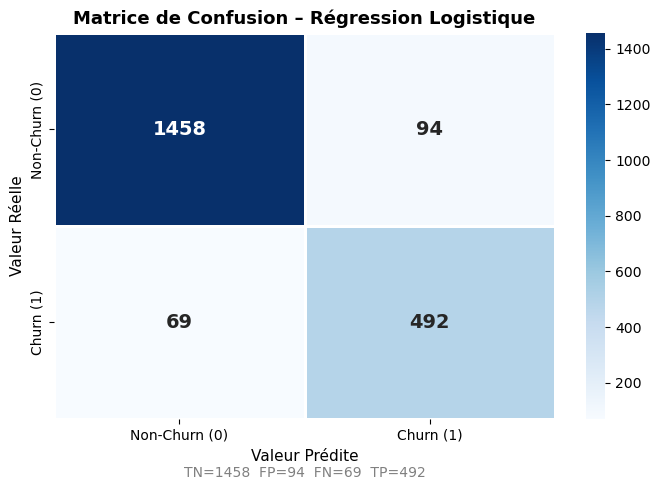

 RÉSULTATS : Random Forest
  Accuracy  : 0.9224  (92.2%)
  Precision : 0.8031
  Recall    : 0.9376
  F1-Score  : 0.8651

              precision    recall  f1-score   support

   Non-Churn       0.98      0.92      0.95      1552
       Churn       0.80      0.94      0.87       561

    accuracy                           0.92      2113
   macro avg       0.89      0.93      0.91      2113
weighted avg       0.93      0.92      0.92      2113



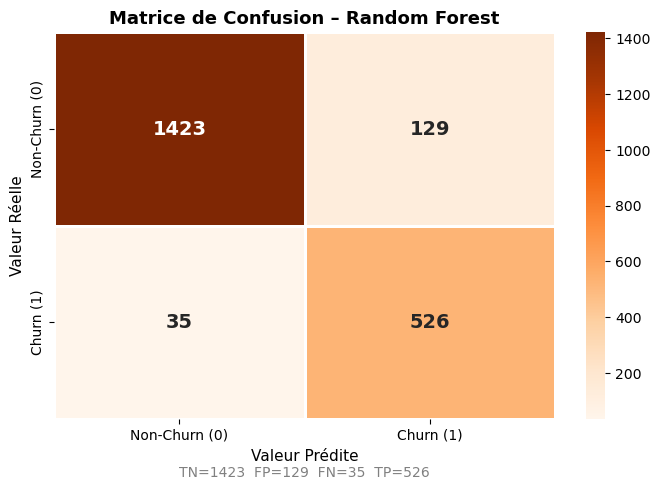

In [37]:


def evaluate_model(model, X_test, y_test, model_name, color='Blues'):

   # Évalue un modèle et affiche :
    #- La matrice de confusion, Les métriques (accuracy, precision, recall, F1),Le rapport de classification complet
    
    # Prédictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilité de la classe 1
    
    # Métriques
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    cm   = confusion_matrix(y_test, y_pred)
    
    # Affichage

    print(f" RÉSULTATS : {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn'])}")
    
    # Matrice de confusion – Heatmap
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=color,
        xticklabels=['Non-Churn (0)', 'Churn (1)'],
        yticklabels=['Non-Churn (0)', 'Churn (1)'],
        linewidths=1, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    plt.title(f'Matrice de Confusion – {model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('Valeur Réelle', fontsize=11)
    plt.xlabel('Valeur Prédite', fontsize=11)
    
    # Annotation des zones
    ax.text(0.5, -0.15, f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}',
            transform=ax.transAxes, ha='center', fontsize=10, color='gray')
    
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'y_prob': y_prob}

# Évaluation des deux modèles
results_lr = evaluate_model(best_lr, X_test_scaled, y_test, 'Régression Logistique', color='Blues')
results_rf = evaluate_model(best_rf, X_test_scaled, y_test, 'Random Forest', color='Oranges')


 TABLEAU COMPARATIF DES PERFORMANCES


,Accuracy,Precision,Recall,F1-Score
Modèle,,,,
Régression Logistique,0.9229,0.8396,0.8770,0.8579
Random Forest,0.9224,0.8031,0.9376,0.8651


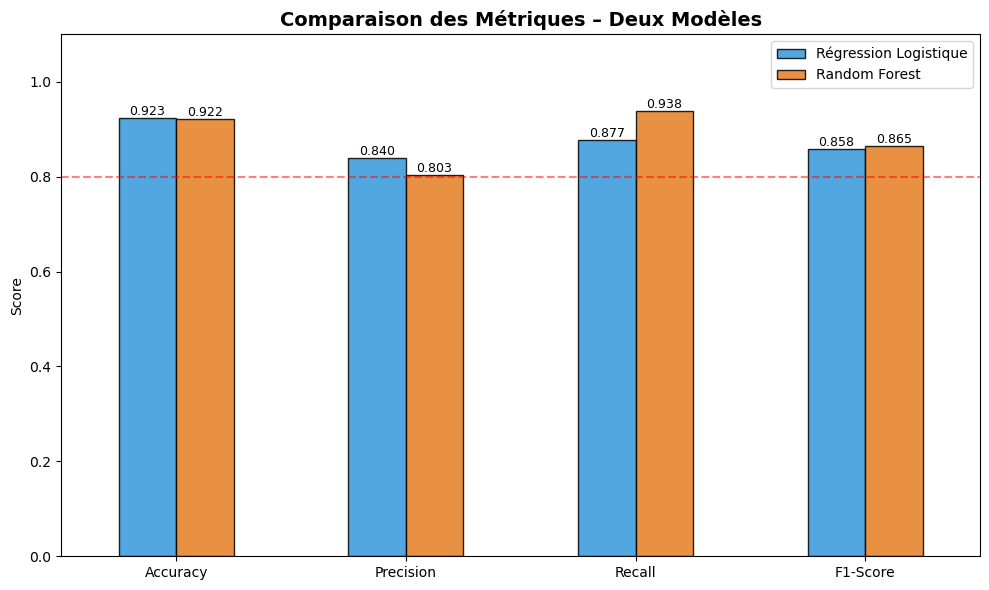

In [38]:

# TABLEAU COMPARATIF DES MÉTRIQUES

metrics_df = pd.DataFrame([
    {
        'Modèle': results_lr['model'],
        'Accuracy': f"{results_lr['accuracy']:.4f}",
        'Precision': f"{results_lr['precision']:.4f}",
        'Recall': f"{results_lr['recall']:.4f}",
        'F1-Score': f"{results_lr['f1']:.4f}"
    },
    {
        'Modèle': results_rf['model'],
        'Accuracy': f"{results_rf['accuracy']:.4f}",
        'Precision': f"{results_rf['precision']:.4f}",
        'Recall': f"{results_rf['recall']:.4f}",
        'F1-Score': f"{results_rf['f1']:.4f}"
    }
])

print("\n" + "="*60)
print(" TABLEAU COMPARATIF DES PERFORMANCES")
print("="*60)
display(metrics_df.set_index('Modèle'))

# Visualisation en barres groupées
metrics_plot = pd.DataFrame({
    'Régression Logistique': [
        results_lr['accuracy'], results_lr['precision'],
        results_lr['recall'], results_lr['f1']
    ],
    'Random Forest': [
        results_rf['accuracy'], results_rf['precision'],
        results_rf['recall'], results_rf['f1']
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

ax = metrics_plot.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e67e22'],
                       edgecolor='black', alpha=0.85)
plt.title('Comparaison des Métriques – Deux Modèles', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Seuil 0.8')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 7️⃣ COURBES ROC & AUC

## Pourquoi la courbe ROC ?

La courbe ROC (Receiver Operating Characteristic) mesure la capacité du modèle à **discriminer** entre les deux classes **pour tous les seuils de décision** possibles (pas seulement 0.5).

- **AUC = 0.5** → Modèle aléatoire (inutile)
- **AUC = 0.7-0.8** → Acceptable
- **AUC > 0.8** → Bon pouvoir discriminant
- **AUC = 1.0** → Modèle parfait (suspect, souvent overfitting)

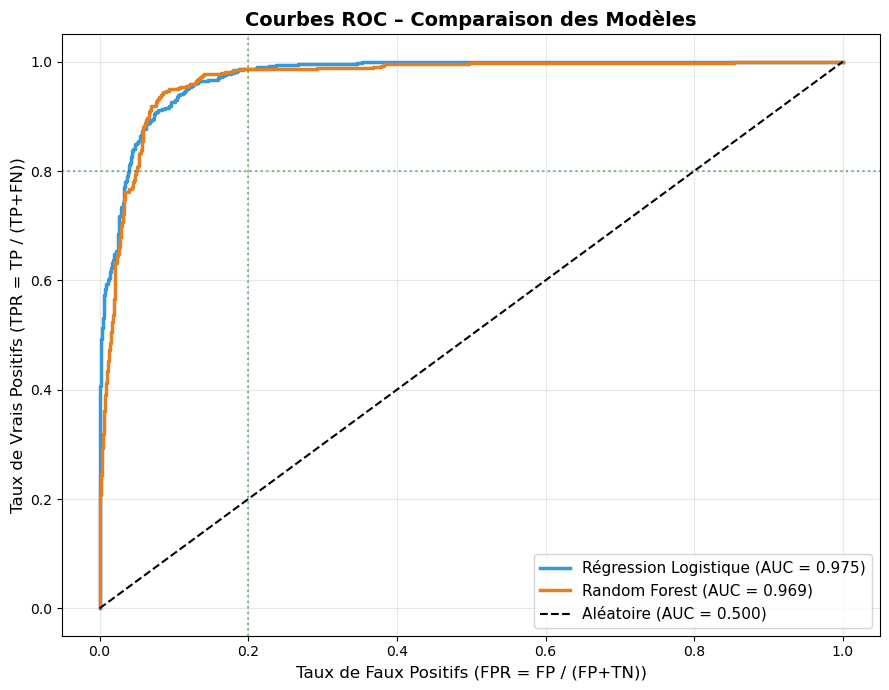


 Interprétation :
   Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.
   AUC > 0.8 → bon pouvoir discriminant pour distinguer churners et non-churners.


In [39]:
#courbe roc
plt.figure(figsize=(9, 7))

# Courbe ROC pour chaque modèle
for result, color, name in [
    (results_lr, '#3498db', 'Régression Logistique'),
    (results_rf, '#e67e22', 'Random Forest')
]:
    fpr, tpr, thresholds = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Ligne de référence (modèle aléatoire)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.500)')

# Zone AUC > 0.8
plt.axhline(y=0.8, color='green', linestyle=':', alpha=0.5)
plt.axvline(x=0.2, color='green', linestyle=':', alpha=0.5)

plt.xlabel('Taux de Faux Positifs (FPR = FP / (FP+TN))', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR = TP / (TP+FN))', fontsize=12)
plt.title('Courbes ROC – Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interprétation :")
print("   Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.")
print("   AUC > 0.8 → bon pouvoir discriminant pour distinguer churners et non-churners.")

---
#8 COURBES D'APPRENTISSAGE

## Pourquoi tracer les Learning Curves ?

Les courbes d'apprentissage permettent de diagnostiquer deux problèmes :

| Situation | Symptôme | Solution |
|---|---|---|
| **Sous-apprentissage** (High Bias) | Train et Val scores tous deux bas | Modèle plus complexe, plus de features |
| **Sur-apprentissage** (High Variance) | Train score élevé, Val score bas | Plus de données, régularisation |
| **Bon équilibre** | Les deux courbes convergent | Modèle prêt |


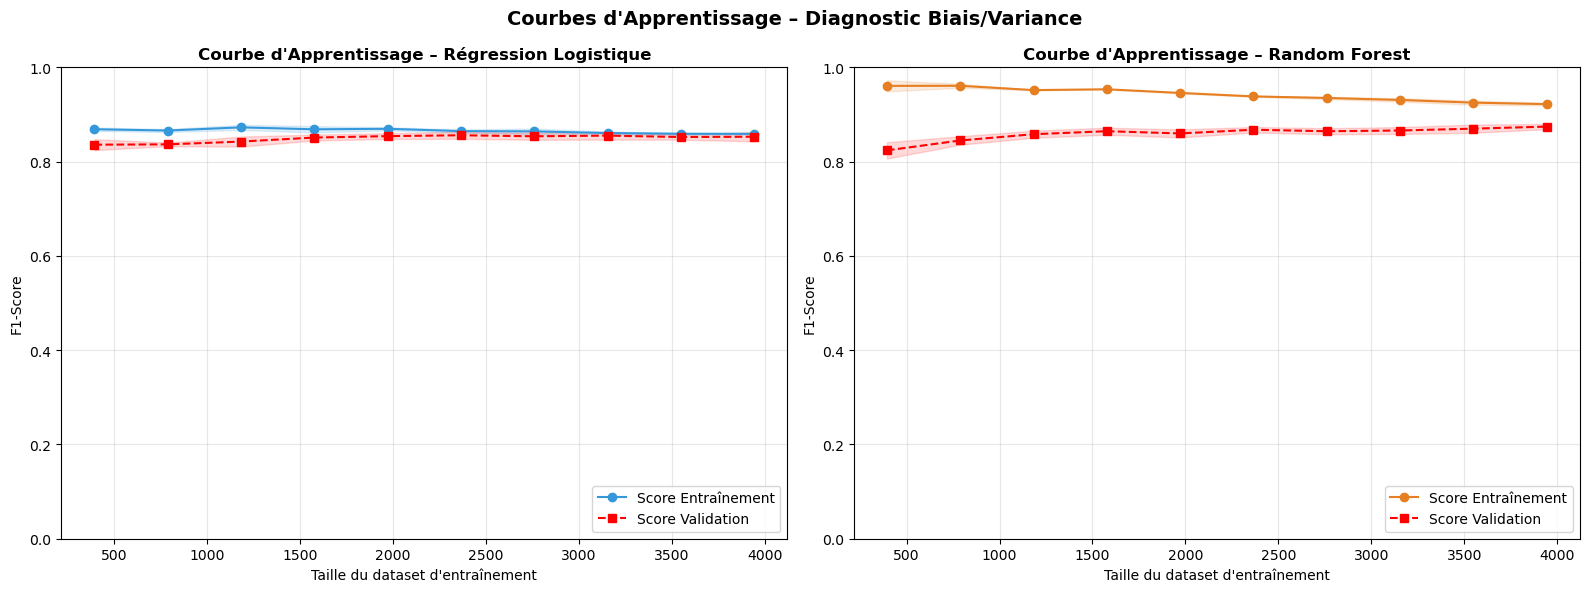

In [40]:
# courbe aprentisage

def plot_learning_curve(model, X, y, model_name, color='blue', ax=None):
    """Trace la courbe d'apprentissage d'un modèle."""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    
    ax.plot(train_sizes, train_mean, 'o-', color=color, label='Score Entraînement')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    
    ax.plot(train_sizes, val_mean, 's--', color='red', label='Score Validation')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
    
    ax.set_title(f'Courbe d\'Apprentissage – {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Taille du dataset d\'entraînement')
    ax.set_ylabel('F1-Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_learning_curve(best_lr, X_train_scaled, y_train, 'Régression Logistique', color='#3498db', ax=axes[0])
plot_learning_curve(best_rf, X_train_scaled, y_train, 'Random Forest', color='#e67e22', ax=axes[1])

plt.suptitle('Courbes d\'Apprentissage – Diagnostic Biais/Variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 9 IMPORTANCE DES FEATURES (Random Forest)

## Pourquoi Random Forest nous donne l'importance des features ?

À chaque split dans un arbre, la forêt mesure **de combien l'impureté diminue (Gini ou entropie).  
En agrégeant ces gains sur tous les arbres, on obtient un score d'importance pour chaque feature.  

Cela permet d'identifier les **drivers principaux du churn directement actionnable métier.

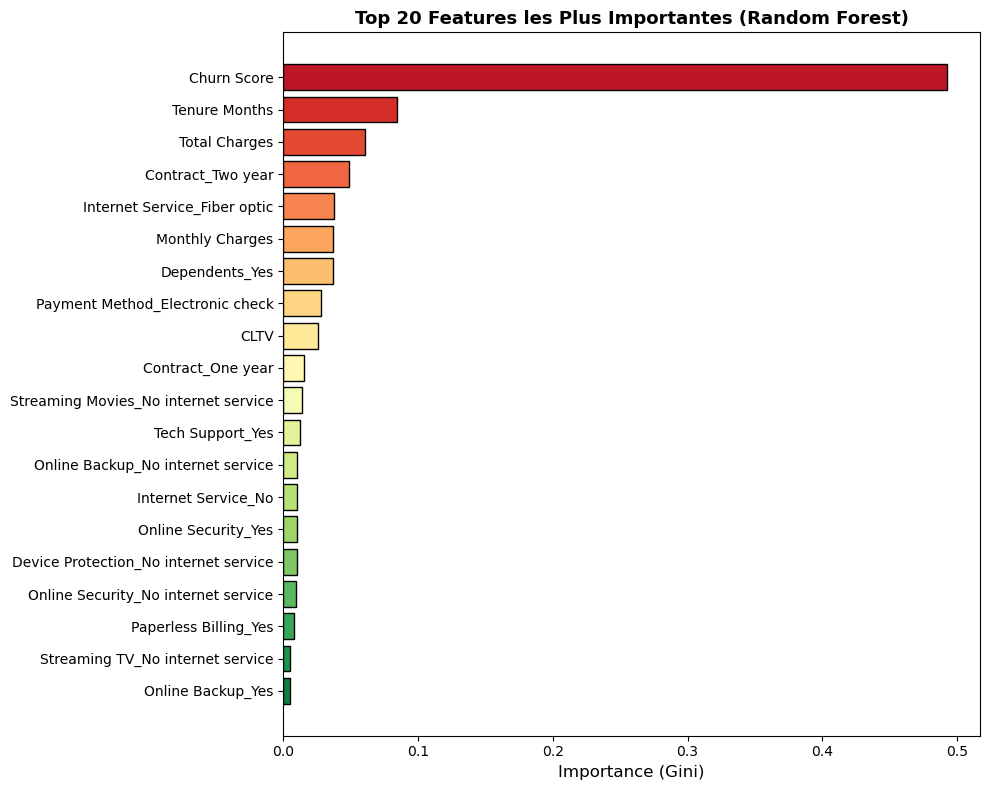


🏆 Top 10 Features :


,Feature,Importance
0,Churn Score,0.492292
1,Tenure Months,0.084395
2,Total Charges,0.060913
3,Contract_Two year,0.048475
4,Internet Service_Fiber optic,0.037586
5,Monthly Charges,0.037003
6,Dependents_Yes,0.036651
7,Payment Method_Electronic check,0.027659
8,CLTV,0.025421
9,Contract_One year,0.015212


In [ ]:

# IMPORTANCE DES FEATURES – RANDOM FOREST

feature_names = X_encoded.columns.tolist()
importances = best_rf.feature_importances_

# Création d'un DataFrame trié
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 20 features
top_n = 20
top_features = feat_imp_df.head(top_n)

plt.figure(figsize=(10, 8))
bars = plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1],
    color=sns.color_palette('RdYlGn', top_n)[::-1],
    edgecolor='black'
)
plt.xlabel('Importance (Gini)', fontsize=12)
plt.title(f'Top {top_n} Features les Plus Importantes (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 10 Features :")
display(top_features.head(10).reset_index(drop=True))

---
## 10 INTERPRÉTATION & RECOMMANDATIONS MÉTIER

## Synthèse des Performances

In [43]:

# RAPPORT DE SYNTHÈSE FINAL


# AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, results_lr['y_prob'])
fpr_rf, tpr_rf, _ = roc_curve(y_test, results_rf['y_prob'])
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

print("="*65)
print(" RAPPORT DE SYNTHÈSE FINAL – PRÉDICTION DU CHURN")
print("="*65)



# Vainqueur
winner = "Random Forest" if results_rf['f1'] > results_lr['f1'] else "Régression Logistique"
print(f"\n Meilleur modèle (F1-Score) : {winner}")

print("""
 RECOMMANDATIONS MÉTIER :

1. PRIORITÉ CLIENTS À RISQUE
   → Cibler en priorité les clients avec contrat mensuel + internet Fiber optic
     car ils présentent les taux de churn les plus élevés.

2. ACTIONS DE RÉTENTION
   → Proposer des offres de passage au contrat annuel (-10% sur facture)
   → Améliorer la qualité du support tech (corrélé au churn élevé)
   → Mettre en place un programme de fidélité pour les clients avec Tenure < 12 mois

3. MODÈLE EN PRODUCTION
   → Utiliser le Random Forest (meilleur AUC et F1)
   → Seuil de décision : ajuster selon le coût de rétention vs coût de perte client
   → Réentraîner le modèle trimestriellement avec les nouvelles données

4. SURVEILLANCE
   → Monitorer le drift des features (Monthly Charges, Tenure) dans le temps
   → Alerter si AUC descend sous 0.75 en production
""")

 RAPPORT DE SYNTHÈSE FINAL – PRÉDICTION DU CHURN

 Meilleur modèle (F1-Score) : Random Forest

 RECOMMANDATIONS MÉTIER :

1. PRIORITÉ CLIENTS À RISQUE
   → Cibler en priorité les clients avec contrat mensuel + internet Fiber optic
     car ils présentent les taux de churn les plus élevés.

2. ACTIONS DE RÉTENTION
   → Proposer des offres de passage au contrat annuel (-10% sur facture)
   → Améliorer la qualité du support tech (corrélé au churn élevé)
   → Mettre en place un programme de fidélité pour les clients avec Tenure < 12 mois

3. MODÈLE EN PRODUCTION
   → Utiliser le Random Forest (meilleur AUC et F1)
   → Seuil de décision : ajuster selon le coût de rétention vs coût de perte client
   → Réentraîner le modèle trimestriellement avec les nouvelles données

4. SURVEILLANCE
   → Monitorer le drift des features (Monthly Charges, Tenure) dans le temps
   → Alerter si AUC descend sous 0.75 en production



---
#  DÉPLOIEMENT STREAMLIT

Le code pour déployer cette application sur Streamlit se trouve dans le fichier `app_streamlit.py`.  
Pour lancer : `streamlit run app_streamlit.py`

---

## Conclusion

Ce projet a démontré comment construire un pipeline ML complet pour la prédiction du churn :

1. **Data Acquisition** → Chargement et inspection du dataset Telco
2. **Préparation** → Nettoyage, encodage OHE, standardisation
3. **Modélisation** → GridSearchCV pour optimiser LR et Random Forest
4. **Évaluation** → Matrice de confusion, Accuracy/Precision/Recall/F1, ROC-AUC
5. **Recommandations** → Actions métier concrètes basées sur les features importantes

**Le Random Forest est le modèle recommandé** pour sa performance supérieure et sa capacité à expliquer les prédictions via l'importance des features.